In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.func import grad
import scipy
import scipy.special
import scipy.linalg
import scipy.integrate
from scipy.linalg import toeplitz, cholesky
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process


torch.set_default_dtype(torch.float64)

In [4]:
def r_squared_exp(t, tau, sigma):
    return sigma**2 * torch.exp(-((t / tau) ** 2))

# Define parameters (as tensors if you wish them to be differentiable)
tau = 1.0
sigma = 1.0

### Plotting the upcrossing integrand as a function of time

In [5]:
u = 1.0
model = formula.GaussianUpCrossings(r_func=r_squared_exp, u=u, tau=tau, sigma=sigma)

In [6]:
t = torch.linspace(0.0001, 10, 1000)

alpha, beta, gamma, delta = model.compute_all_quantities(t, u)

r0 = model.r0
q0 = model.q0
r = model.r(t)
p = model.p(t)
q = model.q(t)

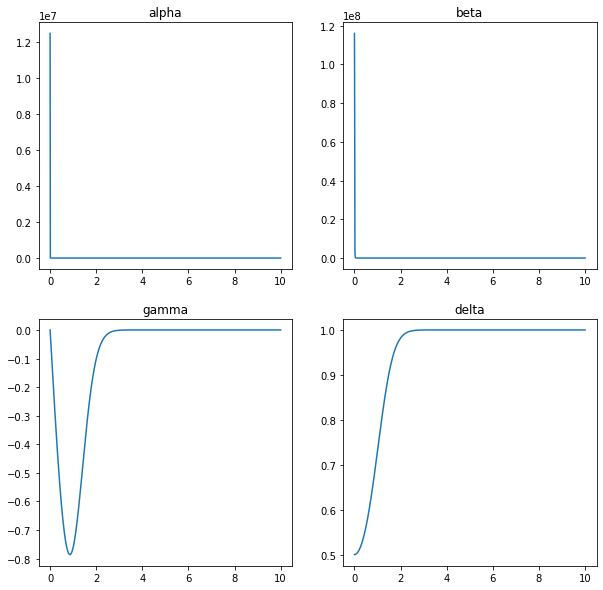

In [7]:
# plot all alpha beta on separate subplots
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].plot(t, alpha)
ax[0, 0].set_title("alpha")
ax[0, 1].plot(t, beta)
ax[0, 1].set_title("beta")
ax[1, 0].plot(t, gamma)
ax[1, 0].set_title("gamma")
ax[1, 1].plot(t, delta)
ax[1, 1].set_title("delta")
plt.show()

In [8]:
val = torch.tensor([0.000001])
print(model._alpha(val))
print(model._beta(val))

tensor([1.2500e+11])
tensor([5650.4303])


Now we test the behavior of the various expressions that appear in the solution.

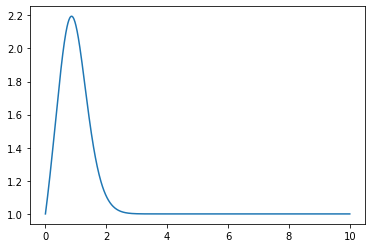

False

In [9]:
expr = torch.exp(-gamma * u**2)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

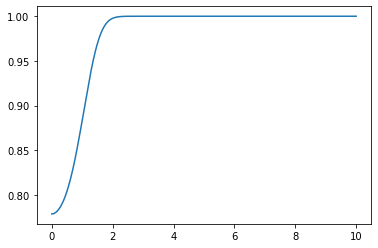

False

In [10]:
expr = torch.exp(-alpha * gamma**2)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

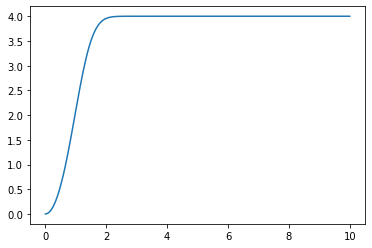

False

In [11]:
expr = 1 / (torch.sqrt((model.r0**2 - model.r(t) ** 2) * (alpha * beta)))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

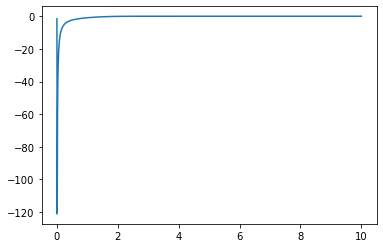

False

In [12]:
expr = gamma * torch.sqrt(alpha + beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

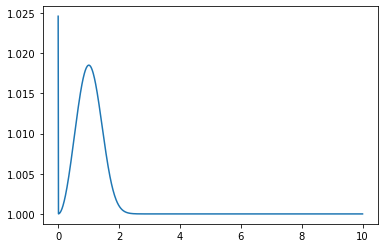

False

In [13]:
expr = torch.exp(alpha**2 * gamma**2 / (alpha + beta))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

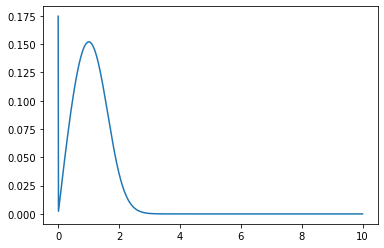

False

In [14]:
expr = torch.special.erf(torch.sqrt(alpha**2 * gamma**2 / (alpha + beta)))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

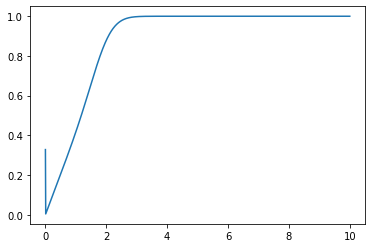

False

In [15]:
expr = torch.sqrt(alpha / beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

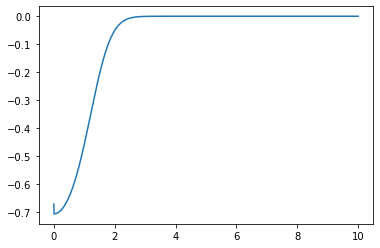

False

In [16]:
expr = gamma * torch.sqrt(2 * alpha * beta / (alpha + beta))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

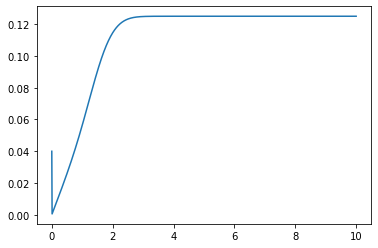

False

In [17]:
expr = scipy.special.owens_t(
    gamma * torch.sqrt(2 * alpha * beta / (alpha + beta)), torch.sqrt(alpha / beta)
)
plt.plot(t, expr)
plt.show()
# print true if any value is nan or not finite
torch.isnan(expr).any() or not torch.isfinite(expr).any()

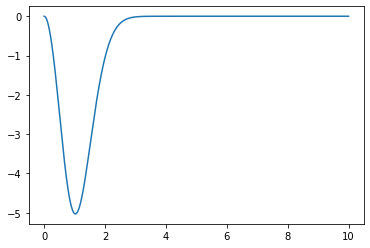

False

In [18]:
expr = (alpha - beta - 2 * alpha * beta * gamma**2) / (alpha * beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

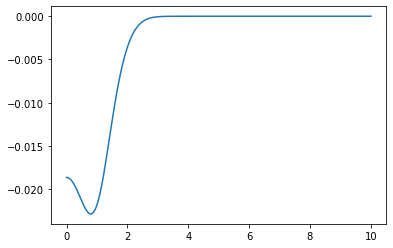

False

In [19]:
expr1 = alpha**2 * gamma**2 / (alpha + beta)

final_integral = (
    torch.exp(-delta * u**2)
    / (4 * torch.pi**2 * torch.sqrt(r0**2 - r**2))
    * (
        (torch.exp(-alpha * gamma**2) / (2 * torch.sqrt(alpha * beta)))
        * (
            1 + np.sqrt(torch.pi) * gamma * torch.sqrt(alpha + beta) * torch.exp(expr1) * torch.special.erf(torch.sqrt(expr1))
        )
        + torch.pi * ((alpha - beta - 2 * alpha * beta * gamma**2) / (alpha * beta))
        * scipy.special.owens_t(gamma * torch.sqrt(2 * alpha * beta / (alpha + beta)), torch.sqrt(alpha / beta))
    )
) - (1 / (4 * torch.pi**2)) * (q0 / r0) * torch.exp(-(u**2) / r0)


plt.plot(t, final_integral)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

In [20]:
# integrate this function ignoring any nan values
integral = torch.trapz(final_integral[~torch.isnan(final_integral)], t[~torch.isnan(final_integral)])
integral

tensor(-0.0344)

In [21]:
t_new = torch.linspace(0.001, 1.0, 1000)
new_integrand = model.upcrossing_integrand(t_new / (1 - t_new), u=u) / (1 - t_new)**2
print(torch.trapz(new_integrand[~torch.isnan(new_integrand)], t_new[~torch.isnan(new_integrand)]))

tensor(-0.0344)


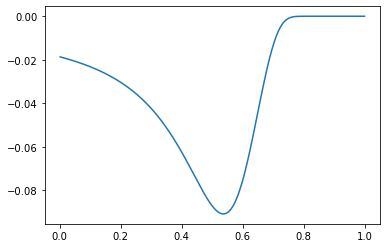

In [22]:
plt.plot(t_new, new_integrand)
plt.show()

### We check if the integrand that we get for mean level crossings (u=0) is a special case of the other one.

In [24]:
u = 0.0
model = formula.GaussianUpCrossings(r_func=r_squared_exp, u=u, tau=tau, sigma=sigma)

t_new = torch.linspace(0.001, 1.0, 1000)
x = t_new / (1 - t_new)

upcrossing_integrand_general = model.upcrossing_integrand(x, u=u) / (1 - t_new)**2
print(torch.trapz(upcrossing_integrand_general[~torch.isnan(upcrossing_integrand_general)], t_new[~torch.isnan(upcrossing_integrand_general)]))

tensor(-0.0803)


In [25]:
upcrossing_integrand = model.upcrossing_integrand_mean_level(x) / (1 - t_new)**2
print(torch.trapz(upcrossing_integrand[~torch.isnan(upcrossing_integrand)], t_new[~torch.isnan(upcrossing_integrand)]))

tensor(-0.0803)


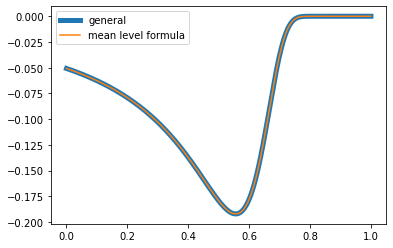

In [26]:
plt.plot(t_new, upcrossing_integrand_general, label="general", linewidth=5)
plt.plot(t_new, upcrossing_integrand, label="mean level formula")
plt.legend()
plt.show()

In [28]:
u = 0.0
model = formula.GaussianUpCrossings(r_func=r_squared_exp, u=u, tau=tau, sigma=sigma)

t_new = torch.linspace(0.001, 1.0, 1000)
x = t_new / (1 - t_new)

crossing_integrand_general = model.crossing_integrand(x, u=u) / (1 - t_new)**2
print(torch.trapz(crossing_integrand_general[~torch.isnan(crossing_integrand_general)], t_new[~torch.isnan(crossing_integrand_general)]))

tensor(-0.0962)


In [29]:
crossing_integrand = model.crossing_integrand_mean_level(x) / (1 - t_new)**2
print(torch.trapz(crossing_integrand[~torch.isnan(crossing_integrand)], t_new[~torch.isnan(crossing_integrand)]))

tensor(-0.0962)


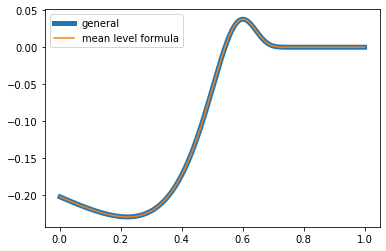

In [30]:
plt.plot(t_new, crossing_integrand_general, label="general", linewidth=5)
plt.plot(t_new, crossing_integrand, label="mean level formula")
plt.legend()
plt.show()

### Checking the results for the filtered OU process

In [31]:
# For a filtered Ornstein-Uhlenbeck process, we have
def r_filtered_OU(t, sigma, tau_e, tau_f):
    zeta = tau_f / tau_e
    return (sigma ** 2 / (1 - zeta ** 2)) * (torch.exp(- torch.abs(t) / tau_e) - zeta * torch.exp(- torch.abs(t) / tau_f))

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_f = 0.01   # Correlation decay parameter
tau_e = 1.0
sigma = 1.0 # Standard deviation (amplitude) of the process

In [34]:
u = 0.0
model = formula.GaussianUpCrossings(r_func=process.r_filtered_OU, u=u, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)

print(model.upcrossing_mean_rate())

tensor(1.5915)
